# 03 — Visualizations & Operational Intelligence
**UIDAI Aadhaar Fraud Intelligence System — Thane District**

---

### Objective
Translate all metrics and findings from Notebooks 01 & 02 into
clear, actionable visualizations for operational decision-making.

### Charts in this notebook

| # | Chart | Source Metric |
|---|---|---|
| 1 | Persistent Identity Churn Distribution | ICI |
| 2 | Biometric Distress Scatter | BDR |
| 3 | Child Biometric Compliance Distribution | CBCR |
| 4 | Enrollment Saturation Distribution | ES |
| 5 | Monthly Trend of Child Biometric Updates | Seasonality |

### Inputs
```
data/processed/master_aadhaar_thane.csv   ← monthly transactions
reports/pin_summary.csv                   ← pincode behavioral profiles
```

### Outputs
```
outputs/01_identity_churn.png
outputs/02_biometric_distress.png
outputs/03_child_compliance.png
outputs/04_enrol_saturation.png
outputs/05_child_bio_trend.png
```

## Cell 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ── Plot config ───────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize'  : (11, 6),
    'axes.titlesize'  : 14,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})

# ── Paths ─────────────────────────────────────────────────────
DATA_PATH    = '../data/processed/master_aadhaar_thane.csv'
PIN_PATH     = '../reports/pin_summary.csv'
OUTPUTS_DIR  = '../outputs'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── Load ──────────────────────────────────────────────────────
monthly = pd.read_csv(DATA_PATH)
pin     = pd.read_csv(PIN_PATH)

# Recompute totals needed for trend chart
monthly['enrol_total'] = monthly['enrol_infant'] + monthly['enrol_child'] + monthly['enrol_adult']
monthly['total_txn']   = monthly['bio_total'] + monthly['demo_total'] + monthly['enrol_total']
monthly['month']       = pd.to_datetime(monthly['month'])

print(f"monthly shape : {monthly.shape}")
print(f"pin shape     : {pin.shape}")
print("\nAll data loaded successfully.")

monthly shape : (982, 13)
pin shape     : (96, 18)

All data loaded successfully.


## Cell 2 — Chart 1: Persistent Identity Churn (ICI)

**What this shows:**
- How many pincodes hit the top 10% ICI threshold across different fractions of months
- 68/96 pincodes never hit top-10% → churn is concentrated in a minority of pincodes
- The right tail (fraction > 0.5) = chronic churn zones needing investigation

PINs never in top-10% ICI   : 68 / 96
PINs chronically churning    : 8 / 96


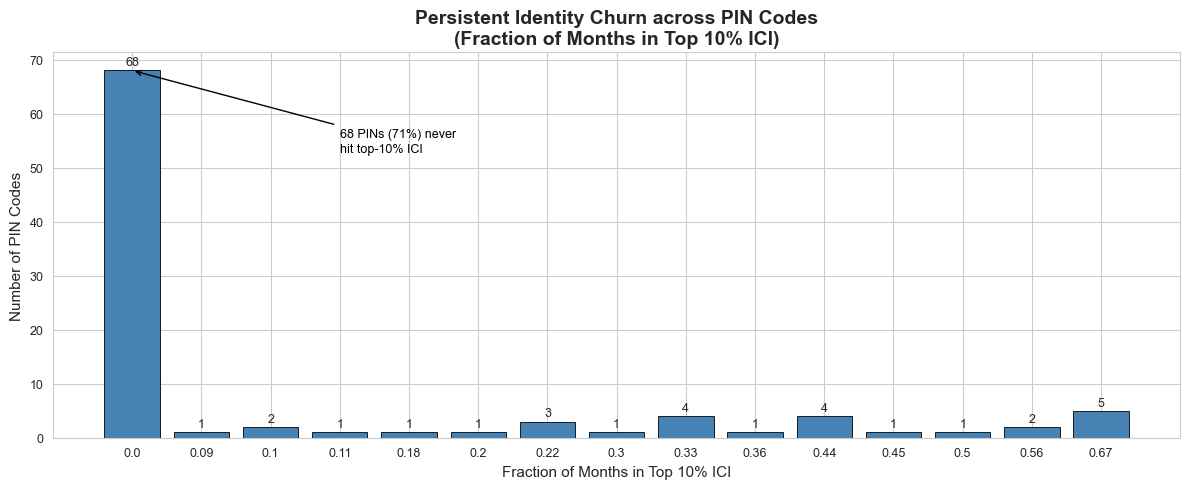

Saved → outputs/01_identity_churn.png


In [2]:
# ── Bin top10_frac into rounded groups ────────────────────────
frac_counts = (
    pin.assign(frac_round=pin['top10_frac'].round(2))
       .groupby('frac_round')
       .agg(num_pins=('pincode','count'))
       .reset_index()
)

never_churn    = (pin['top10_frac'] == 0).sum()
chronic_churn  = (pin['top10_frac'] >= 0.5).sum()
total_pins     = len(pin)

print(f"PINs never in top-10% ICI   : {never_churn} / {total_pins}")
print(f"PINs chronically churning    : {chronic_churn} / {total_pins}")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    frac_counts['frac_round'].astype(str),
    frac_counts['num_pins'],
    color='steelblue',
    edgecolor='black',
    linewidth=0.6
)

# Count labels on each bar
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.4,
            int(h),
            ha='center', va='bottom', fontsize=9
        )

ax.set_title('Persistent Identity Churn across PIN Codes\n(Fraction of Months in Top 10% ICI)')
ax.set_xlabel('Fraction of Months in Top 10% ICI')
ax.set_ylabel('Number of PIN Codes')

# Annotation box
ax.annotate(
    f'{never_churn} PINs (71%) never\nhit top-10% ICI',
    xy=(0, never_churn), xytext=(3, never_churn - 15),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, color='black'
)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/01_identity_churn.png', dpi=150)
plt.show()
print("Saved → outputs/01_identity_churn.png")

## Cell 3 — Chart 2: Biometric Distress Scatter (BDR)

**What this shows:**
- Each dot = one pincode
- X-axis = fraction of months with biometric-only activity (no demographic updates)
- Y-axis = median BDR (biometric pressure intensity)
- **Top-right quadrant** = danger zone: both high bio-only frequency AND high BDR
- Red dashed line at BDR=1 = normal boundary (above = biometrics dominating)

Bio-only high threshold (75th pct) : 0.455
Pincodes in danger zone            : 38


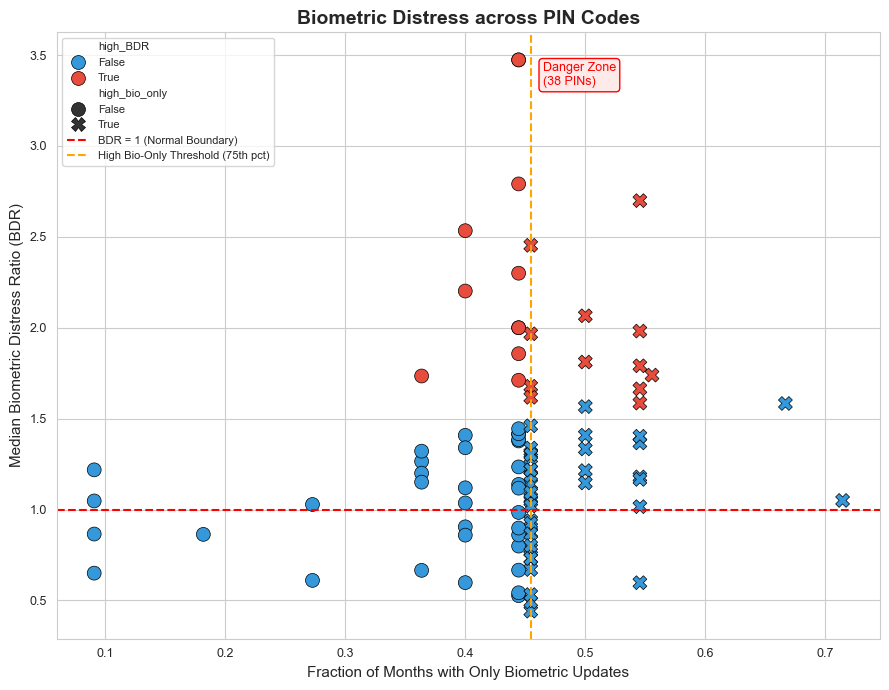

Saved → outputs/02_biometric_distress.png


In [3]:
bio_only_q75 = pin['biometric_only_frac'].quantile(0.75)
bdr_boundary = 1.0

danger_zone = (
    (pin['median_BDR'] > bdr_boundary) &
    (pin['biometric_only_frac'] >= bio_only_q75)
).sum()

print(f"Bio-only high threshold (75th pct) : {bio_only_q75:.3f}")
print(f"Pincodes in danger zone            : {danger_zone}")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=pin,
    x='biometric_only_frac',
    y='median_BDR',
    hue='high_BDR',
    style='high_bio_only',
    palette={True: '#e74c3c', False: '#3498db'},
    s=100,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# Reference lines
ax.axhline(bdr_boundary,  color='red',    linestyle='--', linewidth=1.5, label='BDR = 1 (Normal Boundary)')
ax.axvline(bio_only_q75,  color='orange', linestyle='--', linewidth=1.5, label='High Bio-Only Threshold (75th pct)')

# Danger zone label
ax.text(
    bio_only_q75 + 0.01, ax.get_ylim()[1] * 0.92,
    f'Danger Zone\n({danger_zone} PINs)',
    fontsize=9, color='red',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffeaea', edgecolor='red')
)

ax.set_title('Biometric Distress across PIN Codes')
ax.set_xlabel('Fraction of Months with Only Biometric Updates')
ax.set_ylabel('Median Biometric Distress Ratio (BDR)')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/02_biometric_distress.png', dpi=150)
plt.show()
print("Saved → outputs/02_biometric_distress.png")

## Cell 4 — Chart 3: Child Biometric Compliance (CBCR)

**What this shows:**
- Distribution of mean CBCR across all 96 pincodes
- Most pincodes are right-skewed toward 1.0 — generally compliant
- Left tail (CBCR < 0.4) = pincodes with serious compliance gaps
- Red line = 25th percentile threshold marking low-compliance zone

Low CBCR threshold (25th pct)         : 0.7894
Pincodes with zero compliance (CBCR=0): 3
Pincodes flagged low_CBCR             : 24


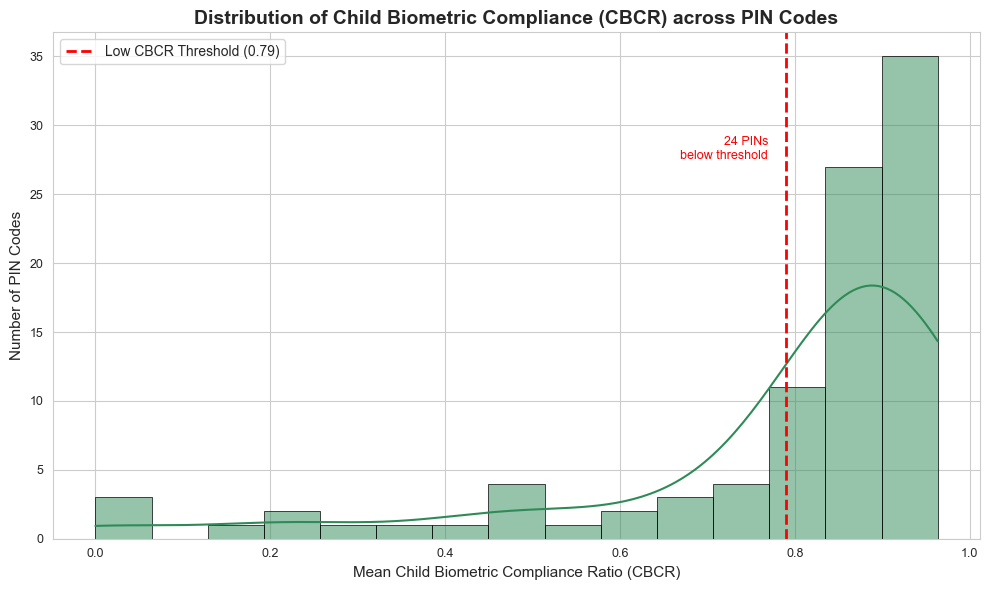

Saved → outputs/03_child_compliance.png


In [4]:
cbcr_cutoff  = pin['mean_CBCR'].quantile(0.25)
zero_compliance = (pin['mean_CBCR'] == 0).sum()
low_compliance  = pin['low_CBCR'].sum()

print(f"Low CBCR threshold (25th pct)         : {cbcr_cutoff:.4f}")
print(f"Pincodes with zero compliance (CBCR=0): {zero_compliance}")
print(f"Pincodes flagged low_CBCR             : {low_compliance}")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    pin['mean_CBCR'],
    bins=15,
    kde=True,
    color='seagreen',
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.axvline(
    cbcr_cutoff,
    color='red', linestyle='--', linewidth=2,
    label=f'Low CBCR Threshold ({cbcr_cutoff:.2f})'
)

# Annotation
ax.text(
    cbcr_cutoff - 0.02, ax.get_ylim()[1] * 0.75,
    f'{low_compliance} PINs\nbelow threshold',
    ha='right', fontsize=9, color='red'
)

ax.set_title('Distribution of Child Biometric Compliance (CBCR) across PIN Codes')
ax.set_xlabel('Mean Child Biometric Compliance Ratio (CBCR)')
ax.set_ylabel('Number of PIN Codes')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/03_child_compliance.png', dpi=150)
plt.show()
print("Saved → outputs/03_child_compliance.png")

## Cell 5 — Chart 4: Enrollment Saturation Distribution

**What this shows:**
- Distribution of median enrollment saturation across all pincodes
- Heavy left skew — most of Thane is already enrolled (saturated)
- Only ~10 pincodes still have significant new enrollment activity
- Important for **capacity planning** — saturated areas need update infrastructure, not enrollment camps

Saturation threshold (25th pct) : 0.006932
Saturated pincodes              : 24 / 96
Still actively enrolling (>4%)  : 6 / 96


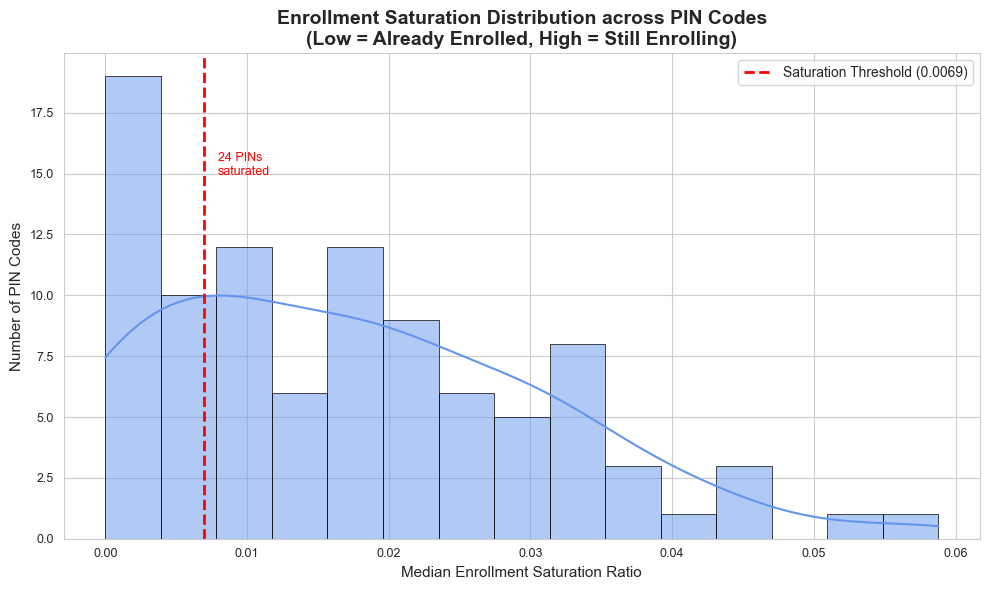

Saved → outputs/04_enrol_saturation.png


In [5]:
sat_cutoff   = pin['median_enrol_sat'].quantile(0.25)
saturated    = pin['is_saturated'].sum()
still_active = (pin['median_enrol_sat'] > 0.04).sum()

print(f"Saturation threshold (25th pct) : {sat_cutoff:.6f}")
print(f"Saturated pincodes              : {saturated} / {len(pin)}")
print(f"Still actively enrolling (>4%)  : {still_active} / {len(pin)}")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    pin['median_enrol_sat'],
    bins=15,
    kde=True,
    color='cornflowerblue',
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

ax.axvline(
    sat_cutoff,
    color='red', linestyle='--', linewidth=2,
    label=f'Saturation Threshold ({sat_cutoff:.4f})'
)

# Annotation
ax.text(
    sat_cutoff + 0.001, ax.get_ylim()[1] * 0.75,
    f'{saturated} PINs\nsaturated',
    ha='left', fontsize=9, color='red'
)

ax.set_title('Enrollment Saturation Distribution across PIN Codes\n(Low = Already Enrolled, High = Still Enrolling)')
ax.set_xlabel('Median Enrollment Saturation Ratio')
ax.set_ylabel('Number of PIN Codes')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/04_enrol_saturation.png', dpi=150)
plt.show()
print("Saved → outputs/04_enrol_saturation.png")

## Cell 6 — Chart 5: Monthly Trend of Child Biometric Updates

**What this shows:**
- District-wide monthly total of child (age 5-17) biometric updates
- Clear seasonal pattern — strong spike in Sep–Nov (school year peak)
- Sharp drop in Jan 2026 — either data cutoff or seasonal end
- Useful for **workforce planning** — centers need more capacity in Q3/Q4

Peak month : Nov 2025 — 45,932 updates
Low  month : Jan 2026  — 4,343 updates


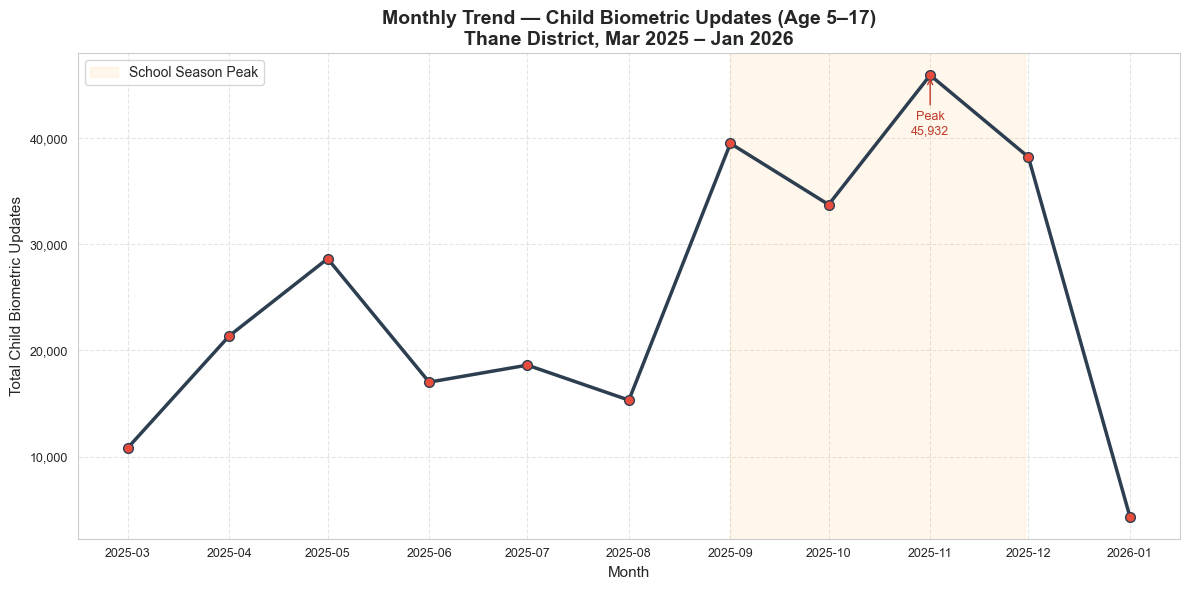

Saved → outputs/05_child_bio_trend.png


In [6]:
# ── Aggregate district-wide monthly child bio updates ─────────
monthly_trend = (
    monthly.groupby('month')
           .agg(
               child_bio_updates = ('bio_child', 'sum'),
               total_txn         = ('total_txn', 'sum')
           )
           .reset_index()
           .sort_values('month')
)

peak_month = monthly_trend.loc[monthly_trend['child_bio_updates'].idxmax()]
low_month  = monthly_trend.loc[monthly_trend['child_bio_updates'].idxmin()]

print(f"Peak month : {peak_month['month'].strftime('%b %Y')} — {int(peak_month['child_bio_updates']):,} updates")
print(f"Low  month : {low_month['month'].strftime('%b %Y')}  — {int(low_month['child_bio_updates']):,} updates")

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_trend['month'],
    monthly_trend['child_bio_updates'],
    marker='o', linewidth=2.5,
    color='#2c3e50', markerfacecolor='#e74c3c',
    markersize=7
)

# Annotate peak
ax.annotate(
    f"Peak\n{int(peak_month['child_bio_updates']):,}",
    xy=(peak_month['month'], peak_month['child_bio_updates']),
    xytext=(peak_month['month'], peak_month['child_bio_updates'] * 0.88),
    ha='center', fontsize=9, color='#c0392b',
    arrowprops=dict(arrowstyle='->', color='#c0392b')
)

# Shade school season
school_start = pd.Timestamp('2025-09-01')
school_end   = pd.Timestamp('2025-11-30')
ax.axvspan(school_start, school_end, alpha=0.08, color='orange', label='School Season Peak')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('Monthly Trend — Child Biometric Updates (Age 5–17)\nThane District, Mar 2025 – Jan 2026')
ax.set_xlabel('Month')
ax.set_ylabel('Total Child Biometric Updates')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/05_child_bio_trend.png', dpi=150)
plt.show()
print("Saved → outputs/05_child_bio_trend.png")

## Cell 7 — Output Summary

In [7]:
charts = [
    '01_identity_churn.png',
    '02_biometric_distress.png',
    '03_child_compliance.png',
    '04_enrol_saturation.png',
    '05_child_bio_trend.png'
]

print("=" * 45)
print("  VISUALIZATION PIPELINE COMPLETE")
print("=" * 45)
for c in charts:
    path   = os.path.join(OUTPUTS_DIR, c)
    status = '✓' if os.path.exists(path) else '✗  MISSING'
    print(f"  {status}  outputs/{c}")
print("=" * 45)

  VISUALIZATION PIPELINE COMPLETE
  ✓  outputs/01_identity_churn.png
  ✓  outputs/02_biometric_distress.png
  ✓  outputs/03_child_compliance.png
  ✓  outputs/04_enrol_saturation.png
  ✓  outputs/05_child_bio_trend.png
